# Global ERA5 + SCOTIA adjustment

This is the single worked example for the package. It uses the authoritative
five-region global geometry and reproduces the established Atlantic
wind/thermohaline decomposition within the same global solve.

**Geometry.** Six GEBCO 1000 m traces define the five regions. The theory
stops at $55^\circ$S; the Atlantic closes at $55^\circ$N, the Indian at
$24.5^\circ$N, and the Pacific at $59^\circ$N.

**Forcing.** ERA5 wind-stress anomalies are converted upstream to vector
Ekman transport $\mathbf{M}_{\mathrm{Ek}}$. SCOTIA supplies the total
northern transport. The southern transport and every internal Ekman section
are derived from the same $\mathbf{M}_{\mathrm{Ek}}$.

**Decomposition.** The total run uses SCOTIA at the northern boundary. The
wind run replaces it with the northern Ekman section; total minus wind is the
thermohaline component. Linearity closes the three components to roundoff.

Here $h_b$ is evaluated at $x_b$, outside the western boundary-current region,
and $h_w$ is the western-boundary thickness. The transport decomposition uses
the legacy $T_{\mathrm{no\ Ek}}$ convention, i.e. geostrophic transport.
Only Hovmöller and contour diagnostics are shown; no spectra or line banks.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import cmocean
import dask
from dask.array.core import PerformanceWarning
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "notebooks"))
DATA_ROOT = Path(os.environ["MOC_EXAMPLE_DATA_ROOT"])

from moc_adjustment_theory import (
    FFTConvention,
    GlobalAdjustmentModel,
    MultiBasinGeometry,
)
from _example_helpers import (
    ekman_transport_from_stress,
    plot_geometry,
    regularization_gamma,
    section_transport,
    stitched_atlantic,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": False})
warnings.filterwarnings("ignore", category=PerformanceWarning)

## Geometry and observed northern forcing

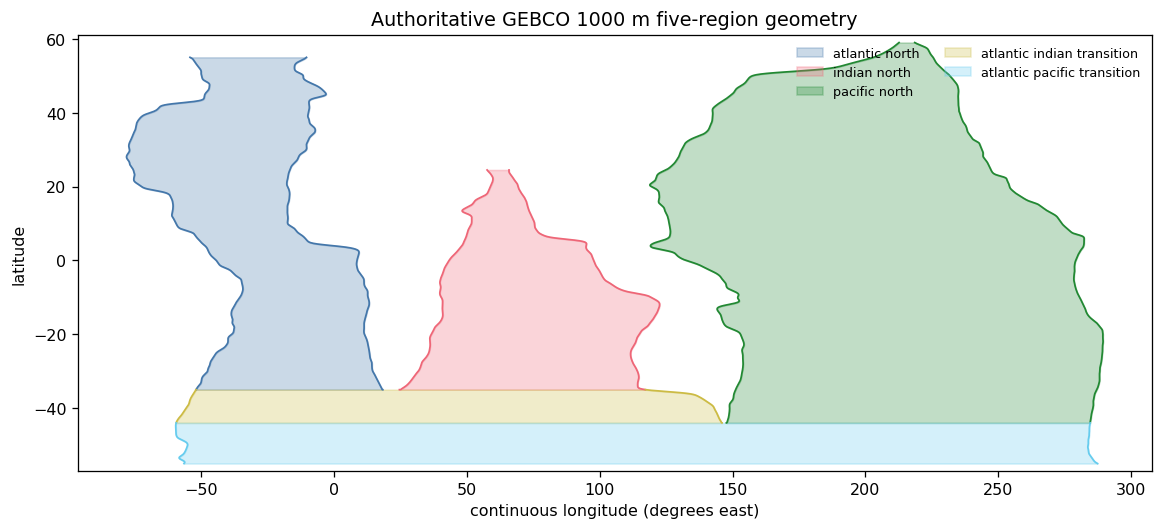

SCOTIA record: 2004-01-01 to 2024-06-01 (246 months)
gateways: y_P=-43.99, y_I=-34.99; closures: y_S=-55, y_N=55, y_NI=24.5, y_NP=59


In [2]:
scotia = xr.open_dataset(
    DATA_ROOT / "SCOTIA/SCOTIA_overturning_diagnostics.nc"
).moc
scotia = scotia.assign_coords(time=scotia.time - np.timedelta64(14, "D"))
scotia.attrs["units"] = "Sv"

isobaths = xr.open_dataset(
    REPO / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc"
).dropna("latitude", how="all")

geometry = MultiBasinGeometry.from_isobath_dataset(isobaths)
region_south = geometry.dataset.region_south
region_north = geometry.dataset.region_north
y_I = float(region_south.sel(region="atlantic_north"))
y_P = float(region_south.sel(region="pacific_north"))
y_S = float(region_south.sel(region="atlantic_pacific_transition"))
y_N = float(region_north.sel(region="atlantic_north"))
y_NI = float(region_north.sel(region="indian_north"))
y_NP = float(region_north.sel(region="pacific_north"))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_geometry(geometry, ax=ax)
ax.set(
    title="Authoritative GEBCO 1000 m five-region geometry",
    ylim=(y_S - 2, y_NP + 2),
)
plt.show()

print(
    f"SCOTIA record: {str(scotia.time.values[0])[:10]} to "
    f"{str(scotia.time.values[-1])[:10]} ({scotia.sizes['time']} months)"
)
print(
    f"gateways: y_P={y_P:.2f}, y_I={y_I:.2f}; "
    f"closures: y_S={y_S:g}, y_N={y_N:g}, y_NI={y_NI:g}, y_NP={y_NP:g}"
)

## ERA5 anomalies and the two linear model runs

Reference density and equatorial regularization are explicit upstream
choices. No basin mask is applied to the wind field: the model uses the
geometry product directly when integrating the supplied Ekman transport.

In [3]:
winds = xr.open_dataset(
    DATA_ROOT / "ERA5/global_winds.nc",
    chunks={},
)[["avg_iews", "avg_inss"]]
winds = winds.assign_coords(
    valid_time=winds.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")
winds = winds.sel(latitude=slice(y_NP, y_S)).sortby("latitude")
winds = winds.sel(time=scotia.time).chunk(
    {"time": -1, "latitude": 24, "longitude": 96}
)
stress_anomaly = winds - winds.mean("time")

rho_0 = 1027.0  # explicitly upstream
g_prime = 0.02
gamma = regularization_gamma(g_prime, geometry.H)
M_Ek = ekman_transport_from_stress(
    stress_anomaly,
    rho_0=rho_0,
    gamma=gamma,
)
T_ek_north = section_transport(
    M_Ek.M_Ek_y,
    geometry,
    region="atlantic_north",
    latitude=y_N,
)
fft = FFTConvention(
        sample_interval_seconds=365.25 * 86_400 / 12,
        padding_samples=scotia.sizes["time"] - 1,
        n_fft=2048,
    )

def solve(T_N):
    forcing = xr.Dataset(
        {"M_Ek_x": M_Ek.M_Ek_x, "M_Ek_y": M_Ek.M_Ek_y, "T_N": T_N}
    )
    return GlobalAdjustmentModel(
        geometry, forcing, fft=fft, g_prime=g_prime
    ).solve()

with dask.config.set(scheduler="threads", num_workers=2):
    total_output = solve(scotia)
    wind_output = solve(T_ek_north)

thermohaline = total_output.dataset - wind_output.dataset
components = {
    "thermohaline": thermohaline,
    "wind": wind_output.dataset,
    "total": total_output.dataset,
}

## Basin-resolved global response

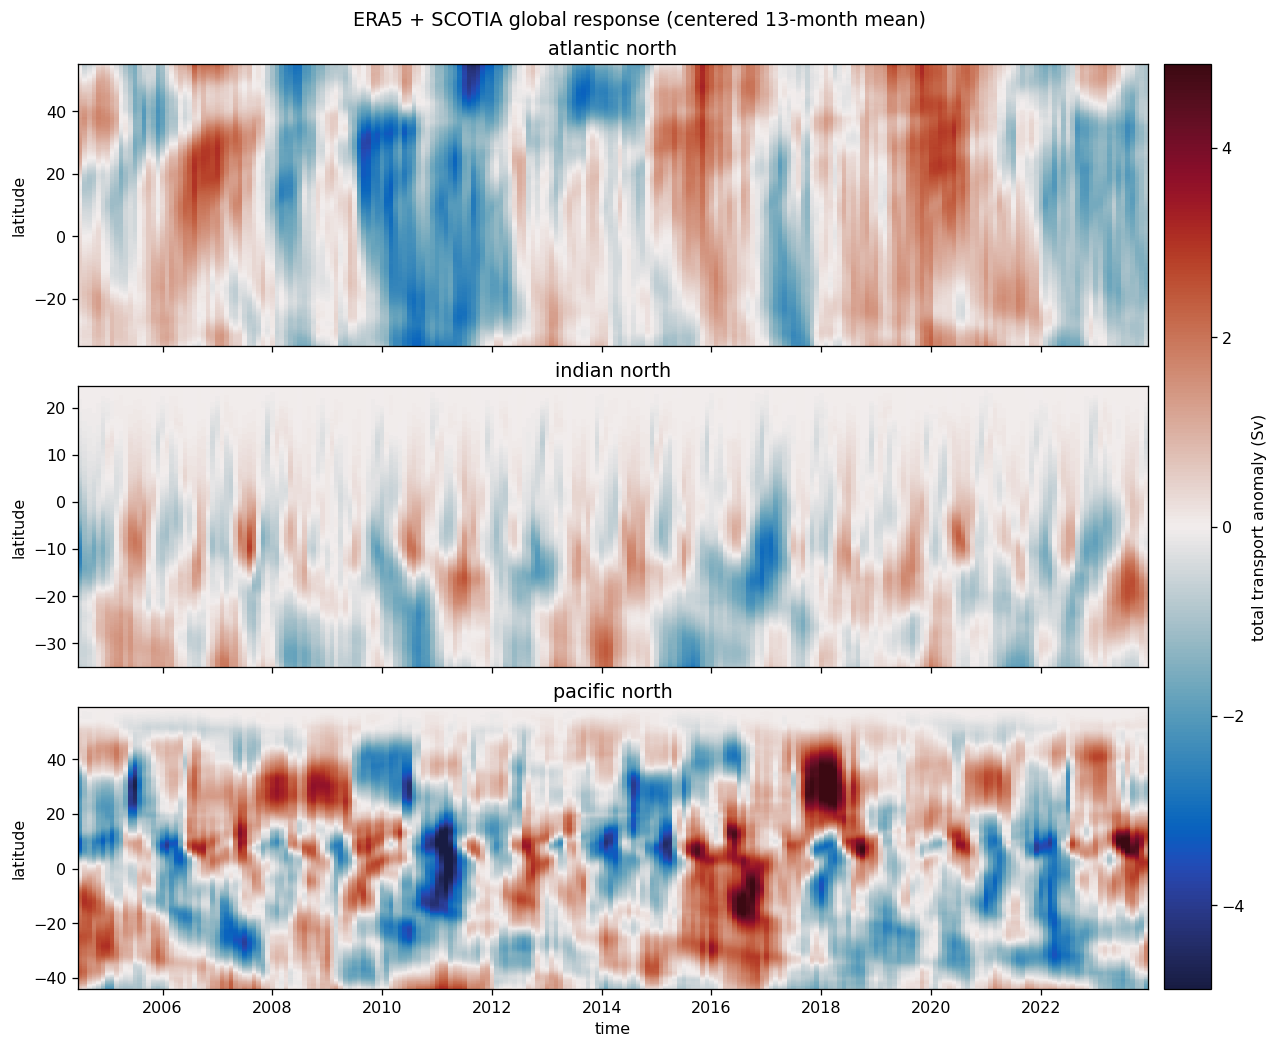

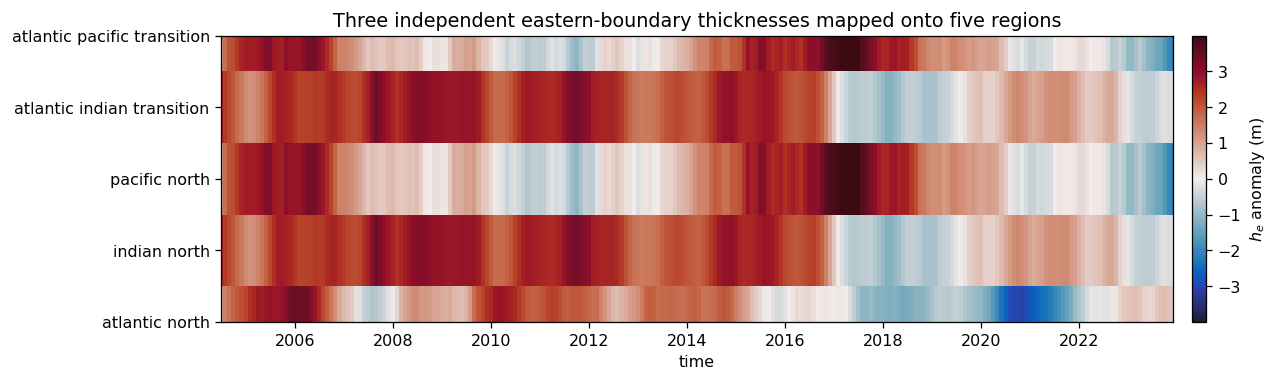

In [4]:
window_months = 13
regions = ["atlantic_north", "indian_north", "pacific_north"]
fields = [
    (total_output.dataset.transport.sel(region=region).dropna("latitude", how="all") / 1e6)
    .rolling(time=window_months, center=True).mean().dropna("time")
    for region in regions
]
vmax = max(float(abs(field).quantile(0.995)) for field in fields)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
for ax, region, field in zip(axes, regions, fields):
    mesh = field.plot.pcolormesh(
        ax=ax,
        x="time",
        y="latitude",
        cmap=cmocean.cm.balance,
        norm=norm,
        add_colorbar=False,
        rasterized=True,
    )
    ax.set(ylabel="latitude", xlabel="", title=region.replace("_", " "))
fig.colorbar(mesh, ax=axes, pad=0.015, label="total transport anomaly (Sv)")
axes[-1].set_xlabel("time")
fig.suptitle(
    f"ERA5 + SCOTIA global response (centered {window_months}-month mean)"
)
plt.show()

he = total_output.dataset.h_e.rolling(time=window_months, center=True).mean().dropna("time")
he = he.assign_coords(
    region=[str(region).replace("_", " ") for region in he.region.values]
)
fig, ax = plt.subplots(figsize=(11, 3.2), constrained_layout=True)
vmax_h = float(abs(he).quantile(0.995))
mesh = he.transpose("region", "time").plot.pcolormesh(
    ax=ax,
    x="time",
    y="region",
    cmap=cmocean.cm.balance,
    norm=mcolors.TwoSlopeNorm(vmin=-vmax_h, vcenter=0.0, vmax=vmax_h),
    add_colorbar=False,
)
fig.colorbar(mesh, ax=ax, pad=0.02, label=r"$h_e$ anomaly (m)")
ax.set(
    title="Three independent eastern-boundary thicknesses mapped onto five regions",
    xlabel="time",
    ylabel="",
)
plt.show()

## Wind-compatibility diagnostic

This inexpensive residual checks the finite-grid divergence theorem. It is
reported rather than imposed as another forcing constraint; it includes
finite-grid differentiation/integration error and flux through the lateral
isobath boundaries.

In [5]:
compatibility = total_output.dataset.compatibility_residual / 1e6
section_imbalance = []
for region in total_output.dataset.transport_ekman.region.values:
    profile = total_output.dataset.transport_ekman.sel(region=region).dropna(
        "latitude", how="all"
    ) / 1e6
    section_imbalance.append(profile.isel(latitude=-1) - profile.isel(latitude=0))
section_imbalance = xr.concat(
    section_imbalance,
    dim=xr.IndexVariable("region", total_output.dataset.transport_ekman.region.values),
)
pumping_integral = compatibility + section_imbalance
rms_residual = np.sqrt((compatibility**2).mean("time"))
rms_reference = xr.apply_ufunc(
    np.maximum,
    np.sqrt((pumping_integral**2).mean("time")),
    np.sqrt((section_imbalance**2).mean("time")),
)
summary = xr.Dataset(
    {
        "rms_Sv": rms_residual,
        "max_abs_Sv": abs(compatibility).max("time"),
        "rms_fraction": rms_residual / rms_reference,
    }
)
print(summary.to_dataframe().round(3).to_string())

                             rms_Sv  max_abs_Sv  rms_fraction
region                                                       
atlantic_north                2.887       7.153         0.742
indian_north                  9.972      21.234         0.719
pacific_north                 3.295       9.418         0.668
atlantic_indian_transition    1.932       5.431         0.380
atlantic_pacific_transition   0.405       1.259         0.042


## Cape Agulhas-to-SPNA decomposition

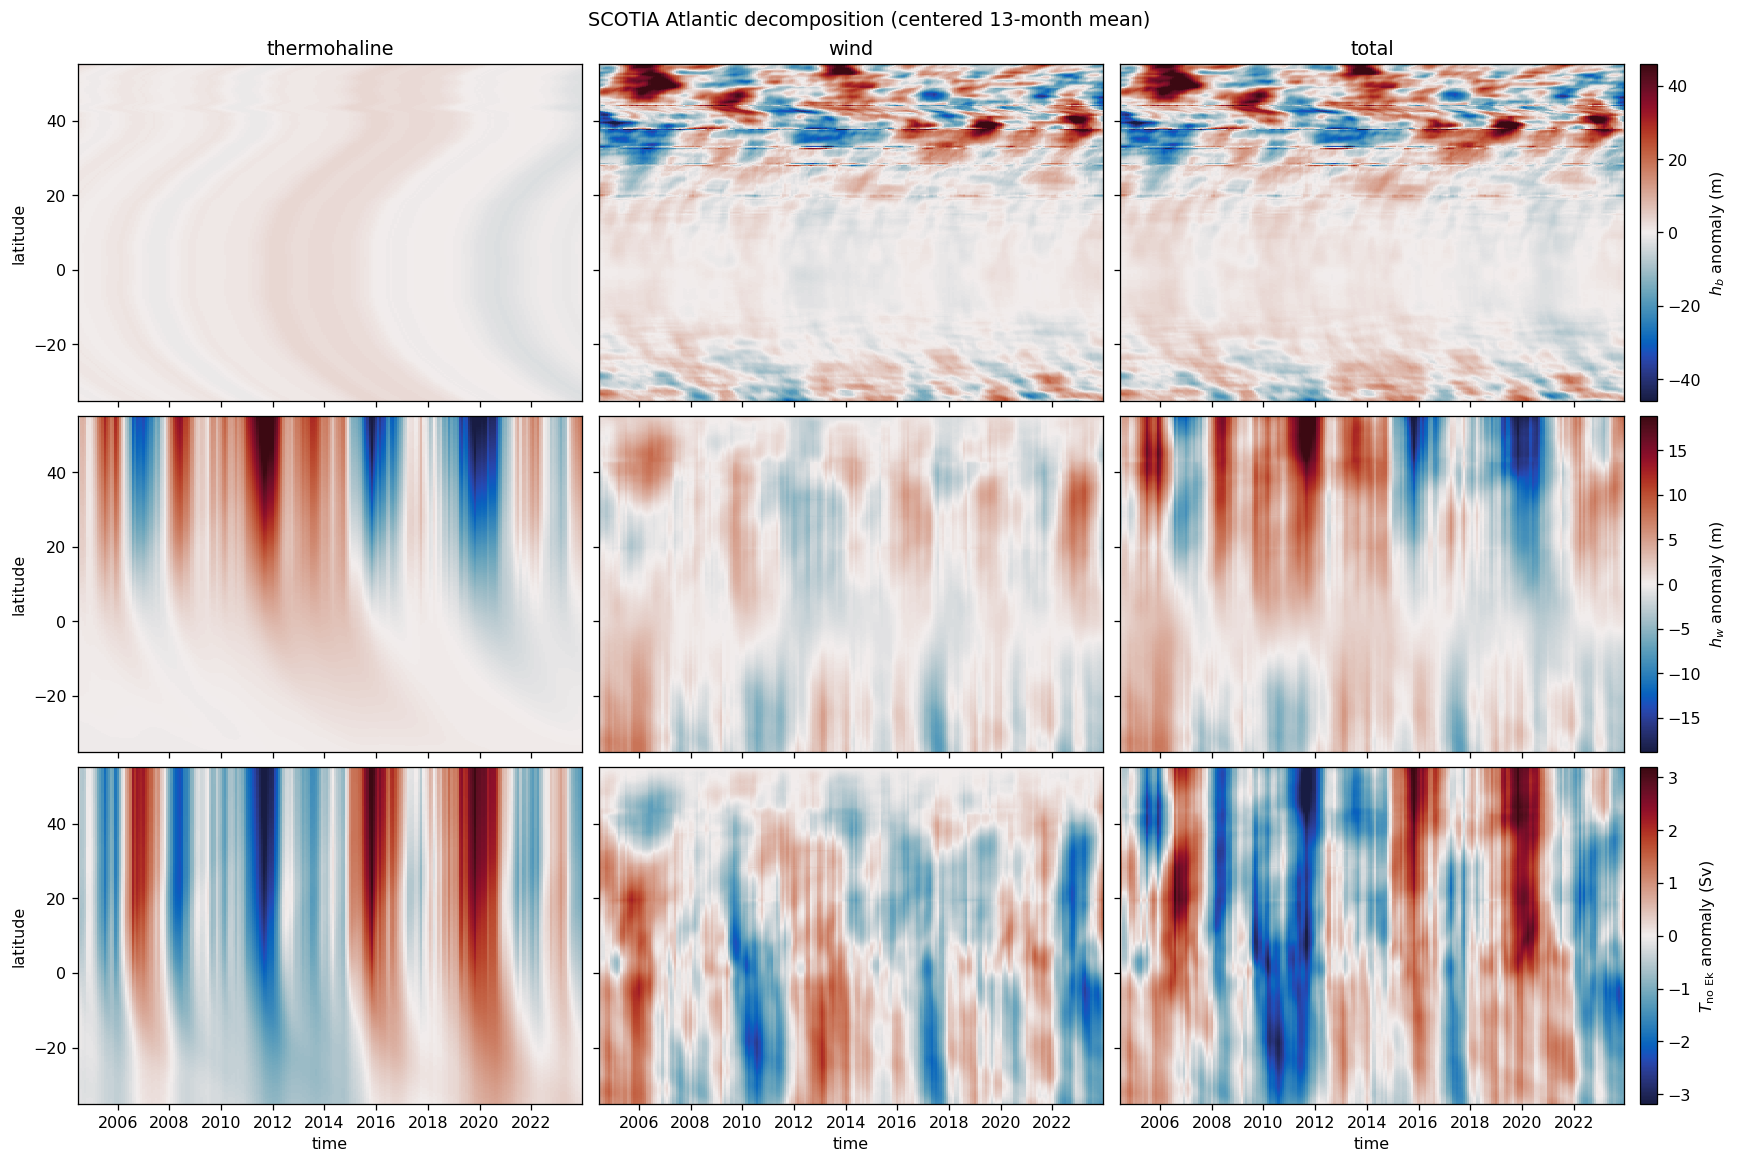

In [6]:
def atlantic_field(dataset, name):
    field = dataset[name].sel(region="atlantic_north").dropna(
        "latitude", how="all"
    )
    if name.startswith("transport"):
        field = field / 1e6
    return field.rolling(time=window_months, center=True).mean().dropna("time")

field_specs = [
    ("h_b", r"$h_b$ anomaly (m)"),
    ("h_w", r"$h_w$ anomaly (m)"),
    ("transport_geostrophic", r"$T_{\mathrm{no\ Ek}}$ anomaly (Sv)"),
]
component_names = list(components)
fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 10),
    sharex=True,
    sharey="row",
    constrained_layout=True,
)
for row, (field_name, colorbar_label) in enumerate(field_specs):
    row_fields = [
        atlantic_field(components[component], field_name)
        for component in component_names
    ]
    vmax = max(float(abs(field).quantile(0.995)) for field in row_fields)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    for column, (component, field) in enumerate(zip(component_names, row_fields)):
        ax = axes[row, column]
        mesh = field.plot.pcolormesh(
            ax=ax,
            x="time",
            y="latitude",
            cmap=cmocean.cm.balance,
            norm=norm,
            add_colorbar=False,
            rasterized=True,
        )
        ax.set(xlabel="", ylabel="latitude" if column == 0 else "", title="")
        if row == 0:
            ax.set_title(component)
    fig.colorbar(mesh, ax=axes[row, :], pad=0.01, label=colorbar_label)
for ax in axes[-1, :]:
    ax.set_xlabel("time")
fig.suptitle(
    f"SCOTIA Atlantic decomposition (centered {window_months}-month mean)"
)
plt.show()

## Northern-boundary damping factor

Subtracting the wind run isolates the response to SCOTIA minus the local
northern Ekman section. Dividing that response by the same boundary forcing
gives the transport transfer amplitude without plotting a forcing spectrum.

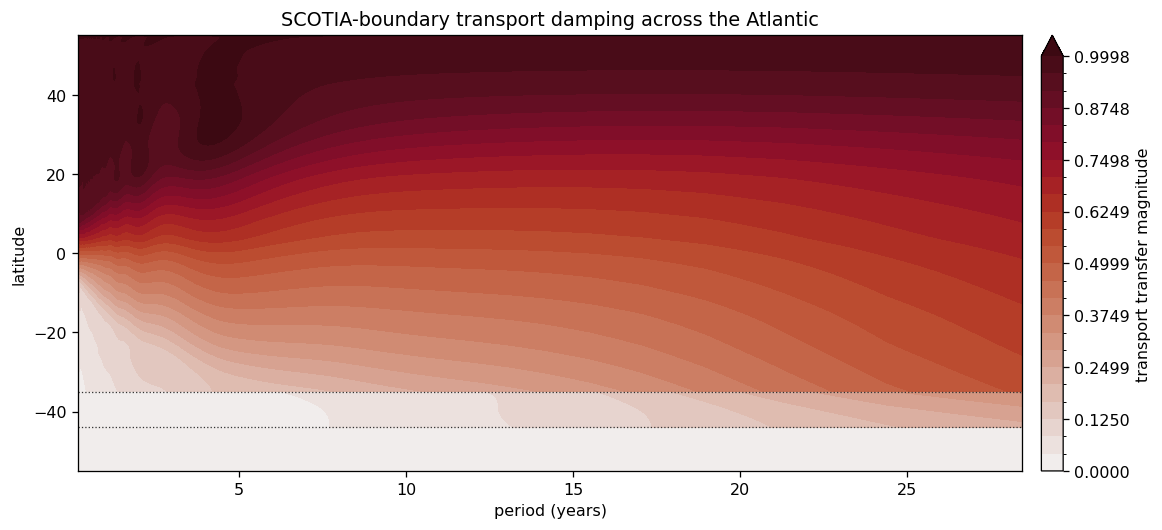

In [7]:
response = stitched_atlantic(
    total_output.spectral.transport - wind_output.spectral.transport,
    geometry,
).isel(omega=slice(1, None))
source = (total_output.spectral.T_N - wind_output.spectral.T_N).isel(
    omega=slice(1, None)
)
valid = abs(source) > float(abs(source).max()) * 1e-10
period_years = (
    2 * np.pi / response.omega / (365.25 * 86_400)
).rename("period_years")
damping = abs(response / source).where(valid).assign_coords(
    period_years=period_years
)
damping = damping.swap_dims({"omega": "period_years"}).sortby("period_years")
damping = damping.sel(period_years=slice(0.0, 30.0))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
levels = np.linspace(0.0, float(damping.quantile(0.99)), 25)
mesh = damping.plot.contourf(
    ax=ax,
    x="period_years",
    y="latitude",
    levels=levels,
    cmap=cmocean.cm.amp,
    extend="max",
    add_colorbar=False,
)
fig.colorbar(mesh, ax=ax, pad=0.02, label="transport transfer magnitude")
ax.axhline(y_P, color="0.2", linestyle=":", linewidth=0.8)
ax.axhline(y_I, color="0.2", linestyle=":", linewidth=0.8)
ax.set(
    xlabel="period (years)",
    ylabel="latitude",
    title="SCOTIA-boundary transport damping across the Atlantic",
)
plt.show()

## Linearity check

In [8]:
closure = {}
for name in ("h_b", "h_w", "transport_geostrophic"):
    reconstructed = thermohaline[name] + wind_output.dataset[name]
    closure[name] = float(abs(total_output.dataset[name] - reconstructed).max())
units = {"h_b": "m", "h_w": "m", "transport_geostrophic": "m3 s-1"}
print("maximum absolute closure error")
for name, value in closure.items():
    print(f"  {name:22s} {value:.3e} {units[name]}")

maximum absolute closure error
  h_b                    8.882e-16 m
  h_w                    7.105e-15 m
  transport_geostrophic  1.863e-09 m3 s-1
